# Week 4 Sync Activity - Data Exploration Challenge

**Welltory COVID-19 and Wearables Open Data Research**

**Alberto Gomez Soteres**

In this notebook, I explore heart rate and heart rate variability (HRV) data from the Welltory COVID-19 dataset.

I focus on heart-related measurements around the start of COVID-19 symptoms. I use `participants.csv` and `hrv_measurements.csv` because these files contain the participant symptom dates and the HRV measurements needed for this analysis.

I do not explore the other files because they are outside the scope of this analysis.

## 1. Imports

Here I first import the libraries needed to load, explore, clean, and visualize the data.

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Data

Here I load the participant information and HRV measurements used in this analysis.

In [129]:
# First we load the two datasets
participants = pd.read_csv("participants.csv")
hrv = pd.read_csv("hrv_measurements.csv")

In [130]:
# Now we look at the first rows of each dataset
display(participants.head())
display(hrv.head())

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,...,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,...,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8..."
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,...,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83..."
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,...,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73..."
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,...,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75..."
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,...,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76..."


## 3. Data Context and Scope

The Welltory dataset contains health data collected from people with COVID-19, including heart rate variability, wearable measurements, symptoms, sleep, weather, and other health information.

For this analysis, I focus on heart rate and heart rate variability around COVID-19 symptom onset. I use:

- `participants.csv` to obtain participant information and symptom onset dates.
- `hrv_measurements.csv` to obtain repeated heart rate and HRV measurements.

I do not explore variables such as sleep, weather, blood pressure, or step count because they are not needed for the focus of this analysis.

### Main Features

The main features used in this analysis are:

- `user_code`: anonymous participant identifier
- `symptoms_onset`: date when COVID-19 symptoms started
- `measurement_datetime`: date and time of the HRV measurement
- `bpm`: heart rate during the measurement
- `sdnn`: a measure of heart rate variability
- `rmssd`: a measure of short-term heart rate variability

### Data Sampling

I use all available rows from `participants.csv` and `hrv_measurements.csv` for the general exploration.

For the symptom-onset analysis, I use only measurements with a valid `symptoms_onset` date and within 30 days before or after symptom onset. This keeps the analysis focused on the period most relevant to the question.

## 4. Data Structure

Here I first check the size, columns, and data types of both datasets. This helps understand how the data is organized before making any changes.

In [131]:
# Check the size of each dataset
print("Participants shape:", participants.shape)
print("HRV measurements shape:", hrv.shape)

Participants shape: (185, 8)
HRV measurements shape: (3245, 22)


In [132]:
# Check the columns in each dataset
print("Participants columns:")
print(participants.columns.tolist())

print("\nHRV columns:")
print(hrv.columns.tolist())

Participants columns:
['user_code', 'gender', 'age_range', 'city', 'country', 'height', 'weight', 'symptoms_onset']

HRV columns:
['user_code', 'rr_code', 'measurement_datetime', 'time_of_day', 'bpm', 'meanrr', 'mxdmn', 'sdnn', 'rmssd', 'pnn50', 'mode', 'amo', 'lf', 'hf', 'vlf', 'lfhf', 'total_power', 'how_feel', 'how_mood', 'how_sleep', 'tags', 'rr_data']


In [133]:
# Check the data types
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_code       185 non-null    object 
 1   gender          185 non-null    object 
 2   age_range       185 non-null    object 
 3   city            173 non-null    object 
 4   country         179 non-null    object 
 5   height          183 non-null    float64
 6   weight          185 non-null    float64
 7   symptoms_onset  147 non-null    object 
dtypes: float64(2), object(6)
memory usage: 11.7+ KB


In [134]:
hrv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             3245 non-null   object 
 1   rr_code               3245 non-null   object 
 2   measurement_datetime  3245 non-null   object 
 3   time_of_day           3245 non-null   object 
 4   bpm                   3245 non-null   int64  
 5   meanrr                3245 non-null   float64
 6   mxdmn                 3245 non-null   float64
 7   sdnn                  3245 non-null   float64
 8   rmssd                 3245 non-null   float64
 9   pnn50                 3245 non-null   float64
 10  mode                  3245 non-null   float64
 11  amo                   3245 non-null   float64
 12  lf                    3245 non-null   float64
 13  hf                    3245 non-null   float64
 14  vlf                   3245 non-null   float64
 15  lfhf                 

In [135]:
# Check how many unique participants are in each dataset
print("Participants:", participants["user_code"].nunique())
print("Participants with HRV measurements:", hrv["user_code"].nunique())

Participants: 185
Participants with HRV measurements: 185


### Interpretation

`participants.csv` contains one row per participant, while `hrv_measurements.csv` contains repeated measurements for the same participants over time.

Both datasets use `user_code` as the participant identifier, which allows them to be combined later in the analysis.

## 5. Descriptive Statistics

Here I check summary statistics for the main heart-related variables. This helps understand their typical values, spread, and range.

In [136]:
# Select the main heart-related variables
heart_features = ["bpm", "sdnn", "rmssd"]

# Check summary statistics
hrv[heart_features].describe().T

,count,mean,std,min,25%,50%,75%,max
bpm,3245.0,73.257935,12.201088,44.000,65.000,72.000,81.000,125.000
sdnn,3245.0,52.489218,29.369506,9.515,32.585,46.919,64.406,206.631
rmssd,3245.0,52.814196,39.353213,6.340,28.985,42.869,62.485,310.800


### Interpretation

The average heart rate is about 73 BPM, with values ranging from 44 to 125 BPM.

For HRV, `sdnn` has a median of about 47 and `rmssd` a median of about 43. Both variables have maximum values much higher than their 75th percentile, which suggests there may be some high outliers.

These possible outliers will be explored later before deciding whether they should be removed.

## 6. Missing Values and Duplicates

Here I check for missing values and duplicate rows in both datasets. This helps assess data completeness and identify repeated records.

In [137]:
# Check missing values in participants.csv
participants.isna().sum()

,0
user_code,0
gender,0
age_range,0
city,12
country,6
height,2
weight,0
symptoms_onset,38


In [138]:
# Check missing values in hrv_measurements.csv
hrv.isna().sum()

,0
user_code,0
rr_code,0
measurement_datetime,0
time_of_day,0
bpm,0
meanrr,0
mxdmn,0
sdnn,0
rmssd,0
pnn50,0


In [139]:
# Check exact duplicate rows
print("Participant duplicates:", participants.duplicated().sum())
print("HRV duplicates:", hrv.duplicated().sum())

Participant duplicates: 0
HRV duplicates: 0


In [140]:
# Remove exact duplicates if any are present
participants = participants.drop_duplicates().copy()
hrv = hrv.drop_duplicates().copy()

No rows were removed because no exact duplicates were found.

### Interpretation

`participants.csv` has some missing values in `city`, `country`, `height`, and `symptoms_onset`. The most relevant missing value for this analysis is `symptoms_onset`, with 38 missing entries.

In `hrv_measurements.csv`, the main heart-related variables used in this analysis (`bpm`, `sdnn`, and `rmssd`) have no missing values. Missing values only appear in `how_sleep` and `tags`, which are not part of the main focus of this analysis.

There are no exact duplicate rows in either dataset.

### Rationale

I do not remove rows with missing `city`, `country`, `height`, `how_sleep`, or `tags` because these variables are not needed for the main analysis.

Participants with missing `symptoms_onset` can still be used for general HRV exploration, but they cannot be used when analyzing measurements around symptom onset.

## 7. Outliers

Here I check for possible outliers in the main heart-related variables. Since health data can naturally contain extreme values, I first identify them before deciding how to handle them.

In [141]:
# Check possible outliers using the IQR method
for column in heart_features:
    q1 = hrv[column].quantile(0.25)
    q3 = hrv[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = hrv[(hrv[column] < lower_bound) | (hrv[column] > upper_bound)]

    print(f"{column}: {len(outliers)} possible outliers")

bpm: 25 possible outliers
sdnn: 149 possible outliers
rmssd: 195 possible outliers


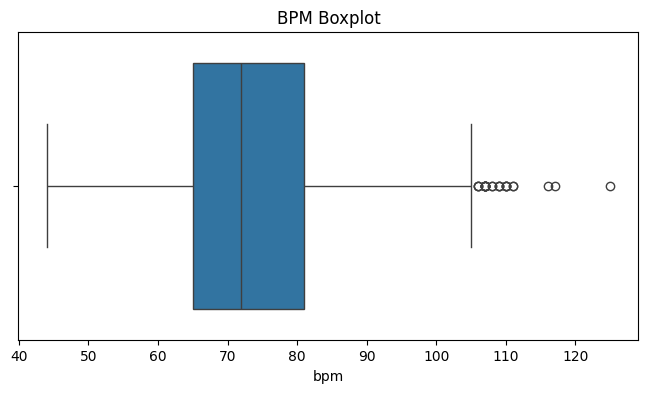

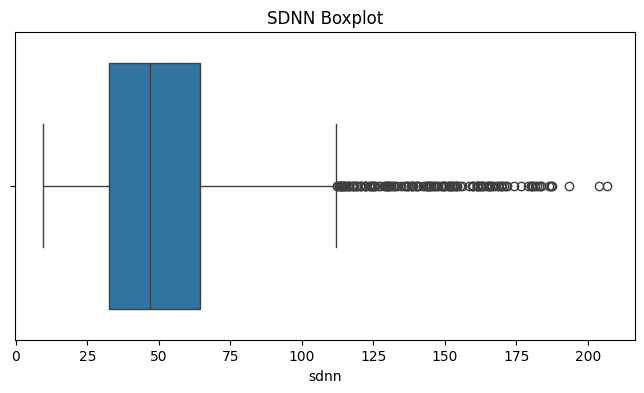

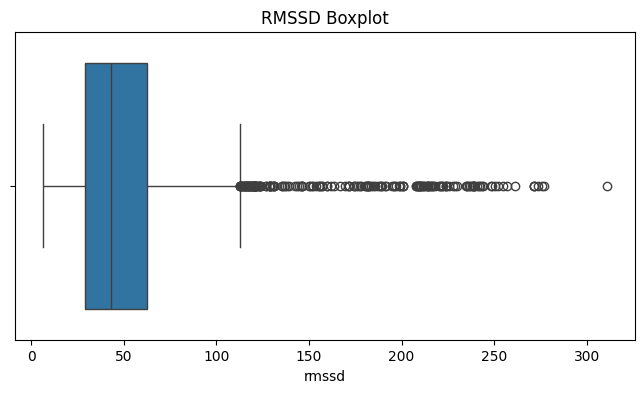

In [142]:
# Visualize possible outliers
for column in heart_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=hrv[column])
    plt.title(f"{column.upper()} Boxplot")
    plt.show()

### Interpretation

The IQR method identifies 25 possible outliers in `bpm`, 149 in `sdnn`, and 195 in `rmssd`.

The boxplots show that most of the possible outliers are high values, especially for `sdnn` and `rmssd`.

I do not remove these values automatically because extreme values in health data may represent real physiological measurements rather than data errors. I keep them in the dataset and interpret them carefully.

## 8. Variable Relationships and Visual Exploration

Here I explore the distributions and relationships between the main heart-related variables. This helps identify patterns that are not as clear from summary statistics alone.

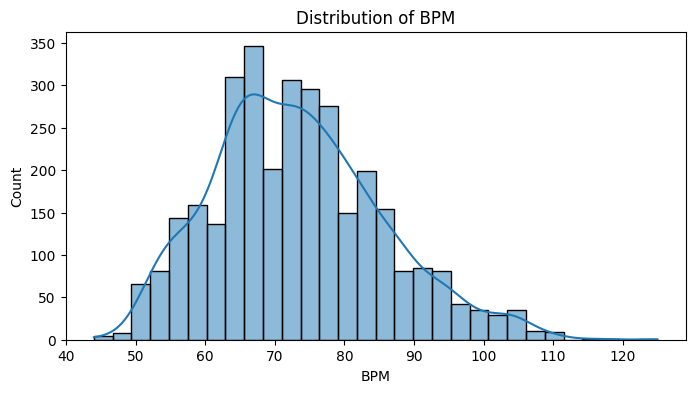

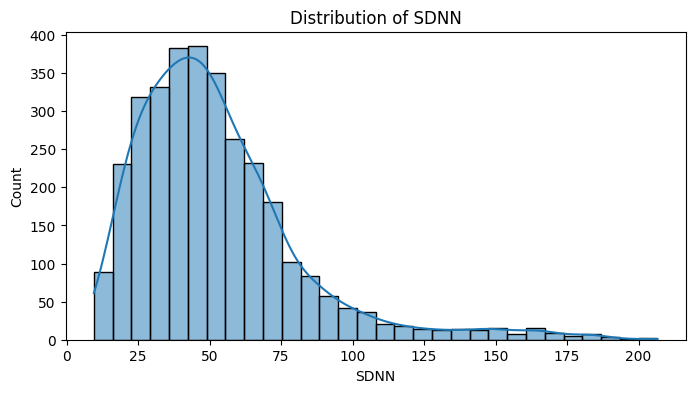

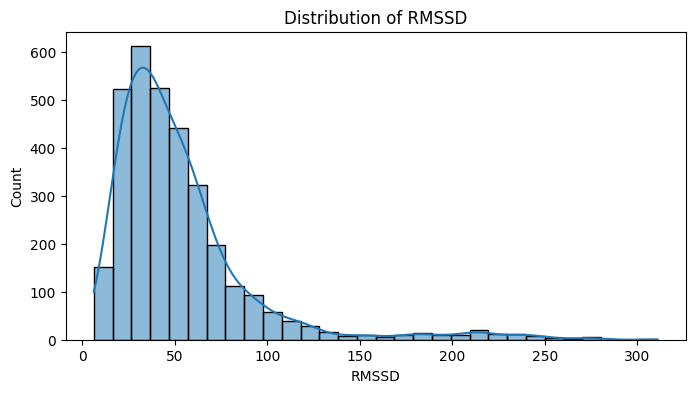

In [143]:
# Plot the distribution of each heart-related variable
for column in heart_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(hrv[column], bins=30, kde=True)
    plt.title(f"Distribution of {column.upper()}")
    plt.xlabel(column.upper())
    plt.ylabel("Count")
    plt.show()

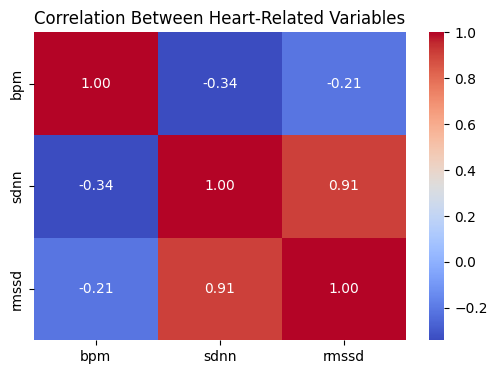

In [144]:
# Check correlations between the main heart-related variables
correlation_matrix = hrv[heart_features].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Heart-Related Variables")
plt.show()

### Interpretation

`bpm` has a more concentrated distribution, while `sdnn` and `rmssd` are right-skewed with long upper tails.

`sdnn` and `rmssd` have a very strong positive correlation (0.91), which makes sense because both are measures of heart rate variability.

`bpm` has a negative relationship with both HRV measures, especially with `sdnn` (-0.34). This suggests that higher heart rate is generally associated with lower heart rate variability in this dataset.

## 9. Data Transformation and Merge

Here I convert the date columns to datetime format and merge the two datasets using `user_code`.

This is needed so I can compare each HRV measurement date with the participant's symptom onset date.

In [145]:
# Convert the date columns to datetime
participants["symptoms_onset"] = pd.to_datetime(
    participants["symptoms_onset"],
    errors="coerce"
)

hrv["measurement_datetime"] = pd.to_datetime(
    hrv["measurement_datetime"],
    errors="coerce"
)

In [146]:
# Merge symptom onset dates into the HRV measurements
merged = hrv.merge(
    participants[["user_code", "symptoms_onset"]],
    on="user_code",
    how="left"
)

merged.head()

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,...,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data,symptoms_onset
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,...,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8...",NaT
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,...,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83...",NaT
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,...,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73...",2020-05-15
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,...,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75...",2020-05-15
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,...,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76...",2020-04-05


### Rationale

I convert the date columns to datetime because they need to be compared and subtracted later.

I use a left merge so all HRV measurements are kept, even if some participants do not have a symptom onset date.

## 10. Feature Engineering

Here I create a new feature called `days_since_symptom_onset`.

This feature measures how many days each HRV measurement occurred before or after the participant's symptom onset date.

In [147]:
# Create the new feature
merged["days_since_symptom_onset"] = (
    merged["measurement_datetime"].dt.normalize()
    - merged["symptoms_onset"]
).dt.days

In [148]:
# Look at the new feature
merged[
    ["measurement_datetime", "symptoms_onset", "days_since_symptom_onset"]
].head(10)

,measurement_datetime,symptoms_onset,days_since_symptom_onset
0,2020-04-21 21:23:08,NaT,NaN
1,2020-04-26 11:19:25,NaT,NaN
2,2020-05-15 04:14:21,2020-05-15,0.0
3,2020-05-19 03:06:02,2020-05-15,4.0
4,2019-12-31 09:07:43,2020-04-05,-96.0
5,2020-01-11 14:52:39,2020-04-05,-85.0
6,2020-01-30 17:55:54,2020-04-05,-66.0
7,2020-04-02 12:07:09,2020-04-05,-3.0
8,2020-04-12 15:00:58,2020-04-05,7.0
9,2020-04-13 19:17:50,2020-04-05,8.0


### Interpretation

Negative values represent measurements taken before symptom onset, `0` represents the symptom onset day, and positive values represent measurements taken after symptoms started.

Measurements from participants without a symptom onset date have a missing value for this feature.

## 11. Explore the New Feature

Here I use the new feature to compare heart-related measurements around symptom onset.

I focus on measurements from 30 days before to 30 days after symptom onset so the analysis stays centered on the period closest to when symptoms started.

In [149]:
# Keep only measurements with a valid symptom-onset feature
symptom_data = merged.dropna(subset=["days_since_symptom_onset"]).copy()

# Keep measurements within 30 days before and after symptom onset
onset_window = symptom_data[
    symptom_data["days_since_symptom_onset"].between(-30, 30)
].copy()

In [150]:
# Calculate the average heart measurements for each day
daily_onset = (
    onset_window
    .groupby("days_since_symptom_onset")[heart_features]
    .mean()
    .reset_index()
)

daily_onset.head()

,days_since_symptom_onset,bpm,sdnn,rmssd
0,-30.0,76.428571,43.743143,47.171857
1,-29.0,77.333333,36.425333,36.518833
2,-28.0,81.166667,30.414667,29.725000
3,-27.0,77.500000,33.372250,42.244250
4,-26.0,82.900000,43.264200,45.559800


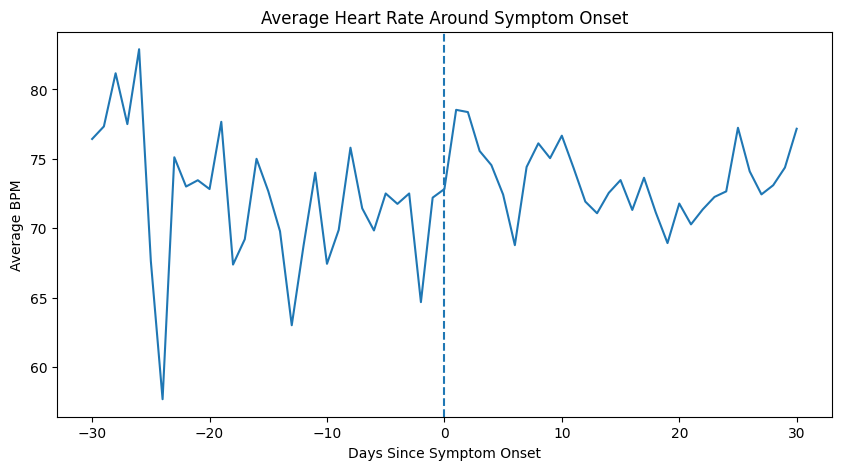

In [151]:
# Plot average heart rate around symptom onset
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=daily_onset,
    x="days_since_symptom_onset",
    y="bpm"
)

plt.axvline(0, linestyle="--")
plt.title("Average Heart Rate Around Symptom Onset")
plt.xlabel("Days Since Symptom Onset")
plt.ylabel("Average BPM")
plt.show()

### Interpretation

The plot shows how average heart rate changes during the 30 days before and after symptom onset.

There is some variation across days, but the pattern is not completely smooth. This is expected because the number of measurements and participants may differ from day to day.

The new feature makes it possible to align measurements from different participants around the same reference point: symptom onset.

## 12. Data Quality Assessment

Here I summarize the main data quality considerations found during the exploration.

### Data Profiling
The data includes 185 participants and 3,245 HRV measurements, with multiple measurements for some participants.

### Completeness
`bpm`, `sdnn`, and `rmssd` have no missing values. However, 38 participants are missing `symptoms_onset`, so those records cannot be used in the symptom-onset analysis.

### Accuracy
Some extreme heart-related values were found using the IQR method. I kept them because they may still be real physiological measurements.

### Consistency
Both datasets use `user_code`, which makes it possible to match participant information with HRV measurements.

### Integrity
No exact duplicate rows were found, and the left join keeps all HRV measurements when the datasets are merged.

### Lineage and Provenance
The data comes from the Welltory COVID-19 and Wearables Open Data Research repository. I use the original `participants.csv` and `hrv_measurements.csv` files.

## 13. Conclusion

This analysis focused on heart rate and HRV around COVID-19 symptom onset.

I explored the main variables, checked missing values, duplicates, outliers, and relationships, and then merged the participant and HRV data.

I also created `days_since_symptom_onset` to compare measurements before and after symptoms started.

Overall, the data had some missing and extreme values, but I handled them based on the needs of the analysis instead of removing them automatically.